In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from core import run_coverage
from config import RESULTS_DIR

In [2]:
# execution
n_sim = 10000
Ts = [100, 500, 1000, 3000]
alpha = 0.05
target_coverage = 1.0 - alpha
for T in Ts:
    test_args = [
            "--T", str(T),
            "--n_sim", str(n_sim),
            "--alpha", str(alpha),
            "--theta", "0.5",
            "--dgps", "iid_normal", "iid_t5", "ar1_phi-06_normal",
            "--models", "iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal",
            #"--th_moments",
            "--seed", "42",
            "--out", str(RESULTS_DIR / f"coverage_T{T}_n{n_sim}.csv")
        ]
    run_coverage.main(test_args)



before:  IIDProcess(Normal(μ=0.0, σ=1.0))
after:  IIDProcess(Normal(μ=0.15, σ=0.3))
before:  IIDProcess(StudentT(μ=0.0, df=5, scale=0.7746))
after:  IIDProcess(StudentT(μ=0.15, df=5, scale=0.2324))
before:  ARProcess(phi=[-0.6], innov=Normal(μ=0.0, σ=1.0), drift=0.0)
after:  ARProcess(phi=[-0.6], innov=Normal(μ=0.0, σ=0.24), drift=0.15)
  [ 1/12]  DGP=iid_normal                    Model=IID Normal             ... 

cov=0.949 [OK]
  [ 2/12]  DGP=iid_normal                    Model=IID Student-t          ... cov=0.943 [OK]
  [ 3/12]  DGP=iid_normal                    Model=IID Non-Normal         ... cov=0.947 [OK]
  [ 4/12]  DGP=iid_normal                    Model=AR(1) Normal           ... cov=0.947 [OK]
  [ 5/12]  DGP=iid_t5                        Model=IID Normal             ... cov=0.924 [!!]
  [ 6/12]  DGP=iid_t5                        Model=IID Student-t          ... cov=0.943 [OK]
  [ 7/12]  DGP=iid_t5                        Model=IID Non-Normal         ... cov=0.933 [!!]
  [ 8/12]  DGP=iid_t5                        Model=AR(1) Normal           ... cov=0.921 [!!]
  [ 9/12]  DGP=ar1_phi-06_normal             Model=IID Normal             ... cov=0.995 [!!]
  [10/12]  DGP=ar1_phi-06_normal             Model=IID Student-t          ... cov=0.995 [!!]
  [11/12]  DGP=ar1_phi-06_normal             Model=IID Non-Normal         ... cov=0.994 [!!]
  [12/12]  DGP=ar1_phi-06_normal             Model=AR(1

In [3]:

alpha = 0.05
target_coverage = 1.0 - alpha 

# 1. Read and combine the data
all_data = []
for T in Ts:
    file_path = RESULTS_DIR / f"coverage_T{T}_n{n_sim}.csv"
    
    # Read the CSV
    df_temp = pd.read_csv(file_path)
    
    # Add the trajectory length 'T' as a column for our x-axis
    df_temp["T"] = T 
    
    all_data.append(df_temp)

# Combine into a single DataFrame
df_results = pd.concat(all_data, ignore_index=True)

# Display the table focusing on the key metrics
columns_to_show = ["T", "dgp_name", "avar_model", "nominal_coverage", "coverage", "bias", "rmse"]
print("=== Combined Results Table ===")
print(df_results[columns_to_show].to_string(index=False))

df_results["dgp_model_pair"] = df_results["dgp_name"] + " + " + df_results["avar_model"]

=== Combined Results Table ===
   T          dgp_name     avar_model  nominal_coverage  coverage      bias     rmse
 100        iid_normal     IID Normal              0.95    0.9494  0.001226 0.107136
 100        iid_normal  IID Student-t              0.95    0.9433  0.003848 0.109003
 100        iid_normal IID Non-Normal              0.95    0.9466  0.001263 0.107098
 100        iid_normal   AR(1) Normal              0.95    0.9467  0.003730 0.107116
 100            iid_t5     IID Normal              0.95    0.9245  0.010788 0.118370
 100            iid_t5  IID Student-t              0.95    0.9434  0.011112 0.116694
 100            iid_t5 IID Non-Normal              0.95    0.9331  0.011199 0.118690
 100            iid_t5   AR(1) Normal              0.95    0.9212  0.010925 0.117755
 100 ar1_phi-06_normal     IID Normal              0.95    0.9946  0.007215 0.073119
 100 ar1_phi-06_normal  IID Student-t              0.95    0.9948  0.008172 0.073496
 100 ar1_phi-06_normal IID Non-Nor

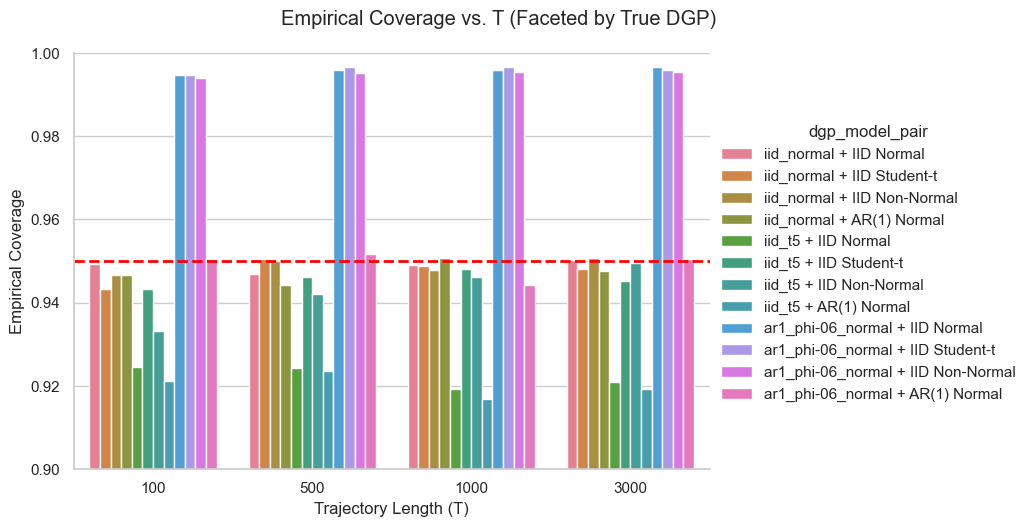

In [4]:
def plot_coverage_results_by_pair(df, target_val=0.95):
    """
    Plots coverage vs. T, faceted by True DGP, with a different color for each Model.
    """
    sns.set_theme(style="whitegrid")
    
    # The 'col' parameter adds the new degree of split for the DGP
    g = sns.catplot(
        data=df_results,
        x="T",
        y="coverage",
        hue="dgp_model_pair", # <-- Uses the combined string
        kind="bar",
        height=5,
        aspect=1.5,
        errorbar=None
    )
    
    # Add the horizontal target line to every subplot
    for ax in g.axes.flat:
        ax.axhline(
            target_val, 
            color='red', 
            linestyle='--', 
            linewidth=2,
            label=f'Target ({target_val})'
        )
        
    # Formatting
    g.fig.suptitle("Empirical Coverage vs. T (Faceted by True DGP)", y=1.05)
    g.set_axis_labels("Trajectory Length (T)", "Empirical Coverage")
    plt.ylim(target_val - 0.05, target_val + 0.05)
    
    plt.show()

# Execute the plot
plot_coverage_results_by_pair(df_results, target_val=target_coverage)

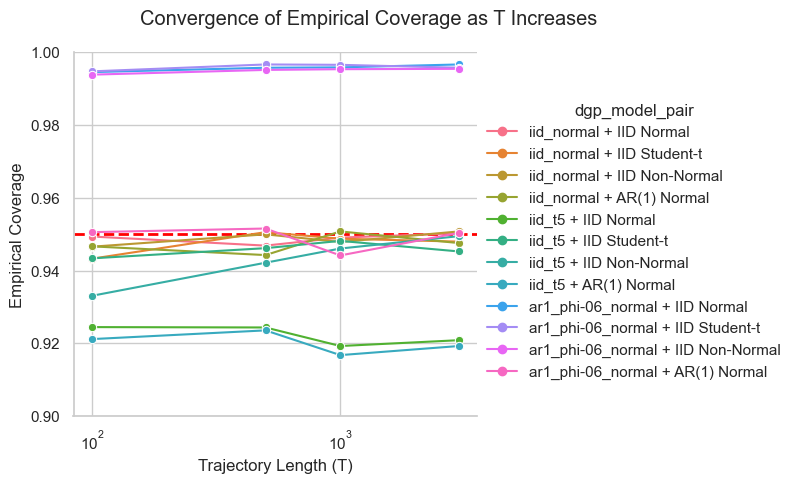

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_coverage_convergence(df, target_val=0.95):
    """
    Plots a line chart showing the convergence of empirical coverage 
    as trajectory length (T) increases, faceted by True DGP.
    """
    sns.set_theme(style="whitegrid")
    
    # Use relplot for continuous variables like T
    g = sns.relplot(
        data=df,
        x="T",
        y="coverage",
        hue="dgp_model_pair", # <-- Uses the combined string
        kind="line",
        marker="o",         # Adds dots at T=100, 500, 1000
        height=4.5,
        aspect=1.2,
        errorbar=None       # Turn off confidence bands 
    )
    
    # Add the horizontal target line to every subplot
    for ax in g.axes.flat:
        ax.axhline(
            target_val, 
            color='red', 
            linestyle='--', 
            linewidth=2,
            zorder=0  # Pushes the red line behind the plotted data lines
        )
        
    # Formatting titles and labels
    g.fig.suptitle("Convergence of Empirical Coverage as T Increases", y=1.05)
    g.set_axis_labels("Trajectory Length (T)", "Empirical Coverage")
    
    for ax in g.axes.flat:
        ax.set_xscale("log")

    plt.ylim(target_val - 0.05, target_val + 0.05)
    
    plt.show()

# Execute the plot
plot_coverage_convergence(df_results, target_val=target_coverage)